In [34]:
import pandas as pd
import pydicom as dicom
import os
import re
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Metadata cleaning and organization

In [35]:
def parse_subject_metadata(s: str) -> list:
    kind = "Calc" if "Calc" in s else "Mass"
    training = "training" if "Training" in s else "Test"
    direction = "LEFT" if "LEFT" in s else "RIGHT"
    acquisition = "MLO" if "MLO" in s else "CC"

    match = re.search(r'(P_\d+)', s)
    subject_id = match.group(1)

    return [kind, training, subject_id, direction, acquisition]

def get_roi_filename_from_folder(folder_path: str)-> str:
    path = Path(folder_path)
    files = [f.name for f in path.iterdir() if f.is_file()]

    for filename in files:
        dicom_file = dicom.dcmread(f"{folder_path}/{filename}", stop_before_pixels=True)

        if "SeriesDescription" not in dicom_file or ("SeriesDescription" in dicom_file and dicom_file["SeriesDescription"].value != "cropped images"):
            return filename

def to_keep(row):
    fullimage_size = (
        dicom.dcmread(row["fullimage filepath"],stop_before_pixels=True).Rows,
        dicom.dcmread(row["fullimage filepath"],stop_before_pixels=True).Columns
    )

    mask_size = (
        dicom.dcmread(row["roi filepath"],stop_before_pixels=True).Rows,
        dicom.dcmread(row["roi filepath"],stop_before_pixels=True).Columns
    )

    if fullimage_size == mask_size:
        return True
    else:
        return False
    

In [36]:
MANIFEST_FILEPATH = "/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest-ZkhPvrLo5216730872708713142"
METADATA_FILEPATH = f"{MANIFEST_FILEPATH}/metadata.csv"
EXPORT_FILEPATH = "/media/gianluca/EXTERNAL_US/CBIS-DDSM"

metadata_df = pd.read_csv(METADATA_FILEPATH)
metadata_df

,Series UID,Collection,3rd Party Analysis,Data Description URI,Subject ID,Study UID,Study Description,Study Date,Series Description,Manufacturer,Modality,SOP Class Name,SOP Class UID,Number of Images,File Size,File Location,Download Timestamp
0,1.3.6.1.4.1.9590.100.1.2.374115997511889073021...,CBIS-DDSM,NaN,https://doi.org/10.7937/K9/TCIA.2016.7O02S9CY,Calc-Test_P_00038_LEFT_CC,1.3.6.1.4.1.9590.100.1.2.859354343102033567126...,NaN,08-29-2017,full mammogram images,NaN,MG,Secondary Capture Image Storage,1.2.840.10008.5.1.4.1.1.7,1,27.84 MB,./CBIS-DDSM/Calc-Test_P_00038_LEFT_CC/08-29-20...,2026-04-27T13:28:55.046136138
1,1.3.6.1.4.1.9590.100.1.2.174390361112646747718...,CBIS-DDSM,NaN,https://doi.org/10.7937/K9/TCIA.2016.7O02S9CY,Calc-Test_P_00038_LEFT_MLO,1.3.6.1.4.1.9590.100.1.2.384159464510350889125...,NaN,08-29-2017,full mammogram images,NaN,MG,Secondary Capture Image Storage,1.2.840.10008.5.1.4.1.1.7,1,28.97 MB,./CBIS-DDSM/Calc-Test_P_00038_LEFT_MLO/08-29-2...,2026-04-27T13:28:57.576149189
2,1.3.6.1.4.1.9590.100.1.2.188613955710170417803...,CBIS-DDSM,NaN,https://doi.org/10.7937/K9/TCIA.2016.7O02S9CY,Calc-Test_P_00038_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.291121996131431385353...,NaN,08-29-2017,ROI mask images,NaN,MG,Secondary Capture Image Storage,1.2.840.10008.5.1.4.1.1.7,2,14.62 MB,./CBIS-DDSM/Calc-Test_P_00038_LEFT_MLO_1/08-29...,2026-04-27T13:29:00.553131239
3,1.3.6.1.4.1.9590.100.1.2.263861248711313923336...,CBIS-DDSM,NaN,https://doi.org/10.7937/K9/TCIA.2016.7O02S9CY,Calc-Test_P_00038_RIGHT_CC,1.3.6.1.4.1.9590.100.1.2.177706148911820252341...,NaN,08-29-2017,full mammogram images,NaN,MG,Secondary Capture Image Storage,1.2.840.10008.5.1.4.1.1.7,1,25.73 MB,./CBIS-DDSM/Calc-Test_P_00038_RIGHT_CC/08-29-2...,2026-04-27T13:29:01.708656457
4,1.3.6.1.4.1.9590.100.1.2.244876997513875090239...,CBIS-DDSM,NaN,https://doi.org/10.7937/K9/TCIA.2016.7O02S9CY,Calc-Test_P_00038_RIGHT_CC_1,1.3.6.1.4.1.9590.100.1.2.200764632211227648028...,NaN,08-29-2017,ROI mask images,NaN,MG,Secondary Capture Image Storage,1.2.840.10008.5.1.4.1.1.7,2,13.41 MB,./CBIS-DDSM/Calc-Test_P_00038_RIGHT_CC_1/08-29...,2026-04-27T13:29:03.980975429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6770,1.3.6.1.4.1.9590.100.1.2.237405159212695555542...,CBIS-DDSM,NaN,https://doi.org/10.7937/K9/TCIA.2016.7O02S9CY,Mass-Training_P_02092_LEFT_CC_1,1.3.6.1.4.1.9590.100.1.2.122076137210534155240...,NaN,07-21-2016,ROI mask images,NaN,MG,Secondary Capture Image Storage,1.2.840.10008.5.1.4.1.1.7,1,11.78 MB,./CBIS-DDSM/Mass-Training_P_02092_LEFT_CC_1/07...,2026-04-27T18:10:47.49525365
6771,1.3.6.1.4.1.9590.100.1.2.321062807811123845106...,CBIS-DDSM,NaN,https://doi.org/10.7937/K9/TCIA.2016.7O02S9CY,Mass-Training_P_02092_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.195655760513031195523...,NaN,07-20-2016,cropped images,NaN,MG,Secondary Capture Image Storage,1.2.840.10008.5.1.4.1.1.7,1,379.24 KB,./CBIS-DDSM/Mass-Training_P_02092_LEFT_MLO_1/0...,2026-04-27T18:10:49.533734843
6772,1.3.6.1.4.1.9590.100.1.2.290251769212905477734...,CBIS-DDSM,NaN,https://doi.org/10.7937/K9/TCIA.2016.7O02S9CY,Mass-Training_P_02092_LEFT_MLO,1.3.6.1.4.1.9590.100.1.2.322851018411213611731...,NaN,07-20-2016,full mammogram images,NaN,MG,Secondary Capture Image Storage,1.2.840.10008.5.1.4.1.1.7,1,37.35 MB,./CBIS-DDSM/Mass-Training_P_02092_LEFT_MLO/07-...,2026-04-27T18:10:53.838629875
6773,1.3.6.1.4.1.9590.100.1.2.150311422512072857220...,CBIS-DDSM,NaN,https://doi.org/10.7937/K9/TCIA.2016.7O02S9CY,Mass-Training_P_02092_LEFT_CC,1.3.6.1.4.1.9590.100.1.2.420341693811920799600...,NaN,07-20-2016,full mammogram images,NaN,MG,Secondary Capture Image Storage,1.2.840.10008.5.1.4.1.1.7,1,31.11 MB,./CBIS-DDSM/Mass-Training_P_02092_LEFT_CC/07-2...,2026-04-27T18:11:05.565569726


In [37]:
metadata_df = pd.read_csv(METADATA_FILEPATH)

# getting all the fullimages filepaths
fullimages_df = pd.DataFrame(
    [ 
        parse_subject_metadata(row["Subject ID"]) + [MANIFEST_FILEPATH + row["File Location"][1:] + "/1-1.dcm"]
        for _, row in metadata_df[metadata_df["Series Description"] == "full mammogram images"].iterrows()
    ],
    columns = ["kind", "training or test", "Subject ID", "breast", "image view", "fullimage filepath"]
)

# getting all the ROIs
rois = []  
for _, row in metadata_df[metadata_df["Series Description"] == "ROI mask images"].iterrows():
    subject_metadata = parse_subject_metadata(row["Subject ID"])
    folder_path = MANIFEST_FILEPATH + row["File Location"][1:]
    roi_filename = get_roi_filename_from_folder(folder_path)
    
    rois.append(subject_metadata + [f"{folder_path}/{roi_filename}"])

# getting all the ROIs
rois_df = pd.DataFrame(
    rois,
    columns = ["kind", "training or test", "Subject ID", "breast", "image view", "roi filepath"]
)

# joining the two dataframes
joined_df = pd.merge(
    left=fullimages_df, 
    right=rois_df,
    how='left',
    left_on=["kind", "training or test", "Subject ID", "breast", "image view"],
    right_on=["kind", "training or test", "Subject ID", "breast", "image view"],
)

# dropna
joined_df = joined_df.dropna(subset = ["fullimage filepath", "roi filepath"])

# drop the entries where the mask doesn't fully match the mammography
joined_df = joined_df[joined_df.apply(to_keep, axis=1)]

# export the final dataset
joined_df.to_csv(f"{EXPORT_FILEPATH}/lesions.csv", index=False)

## Testing that Full image and ROI have correspondence

In [38]:
joined_df = pd.read_csv(f"{EXPORT_FILEPATH}/lesions.csv")

for _, row in joined_df.iterrows():
    subject_id = row["Subject ID"]
    breast = row["breast"]
    view = row["image view"]
    kind = row["kind"]
    
    try:
        fullimage_size = (
            dicom.dcmread(row["fullimage filepath"],stop_before_pixels=True).Rows,
            dicom.dcmread(row["fullimage filepath"],stop_before_pixels=True).Columns
        )
    
        mask_size = (
            dicom.dcmread(row["roi filepath"],stop_before_pixels=True).Rows,
            dicom.dcmread(row["roi filepath"],stop_before_pixels=True).Columns
        )
    except Exception as e:
        print(f"Exception on pateint {subject_id} - {breast} - {view} - {kind}: {e}")

    if fullimage_size != mask_size:
        print(f"{subject_id} - {breast} - {view} - {kind}")

## Visualizing some of the lesions

In [47]:
joined_df = pd.read_csv(f"{EXPORT_FILEPATH}/lesions.csv")

,kind,training or test,Subject ID,breast,image view,fullimage filepath,roi filepath
0,Calc,Test,P_00038,LEFT,CC,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...
1,Calc,Test,P_00038,LEFT,MLO,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...
2,Calc,Test,P_00038,RIGHT,CC,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...
3,Calc,Test,P_00038,RIGHT,CC,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...
4,Calc,Test,P_00038,RIGHT,MLO,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...
...,...,...,...,...,...,...,...
3563,Mass,training,P_02033,RIGHT,MLO,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...
3564,Mass,training,P_02079,RIGHT,CC,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...
3565,Mass,training,P_02079,RIGHT,MLO,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...
3566,Mass,training,P_02092,LEFT,MLO,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...,/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest...


### P_00038 - LEFT CC

P_00038 - LEFT CC
FULLIMAGE: /media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_LEFT_CC/08-29-2017-DDSM-NA-96009/1.000000-full mammogram images-63992/1-1.dcm

ROI: /media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_LEFT_CC_1/08-29-2017-DDSM-NA-94942/1.000000-ROI mask images-18515/1-2.dcm


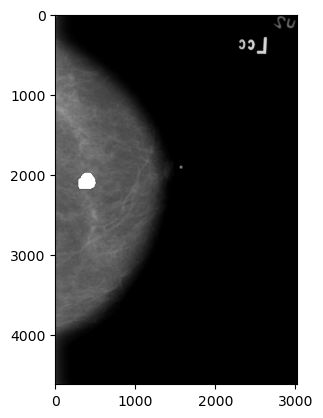

In [41]:
i = 0
subject_id = joined_df.iloc()[i]["Subject ID"]
breast = joined_df.iloc()[i]["breast"]
image_view = joined_df.iloc()[i]["image view"]
#cropped_image_filepath = parsed_df.iloc()[i]["cropped image filepath"]
fullimage_filepath = joined_df.iloc()[i]["fullimage filepath"]
roi_mask_filepath = joined_df.iloc()[i]["roi filepath"]

array = dicom.dcmread(fullimage_filepath).pixel_array
roi = dicom.dcmread(roi_mask_filepath).pixel_array

print(f"{subject_id} - {breast} {image_view}")
print(f"FULLIMAGE: {fullimage_filepath}")
print()
print(f"ROI: {roi_mask_filepath}")
plt.imshow(array, cmap=plt.cm.grey)
plt.imshow(roi, cmap=plt.cm.grey, alpha =(roi>0).astype(float))

### P_00038 - LEFT MLO

P_00038 - LEFT MLO
FULLIMAGE: /media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_LEFT_MLO/08-29-2017-DDSM-NA-17613/1.000000-full mammogram images-97934/1-1.dcm

ROI: /media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_LEFT_MLO_1/08-29-2017-DDSM-NA-11739/1.000000-ROI mask images-88680/1-2.dcm


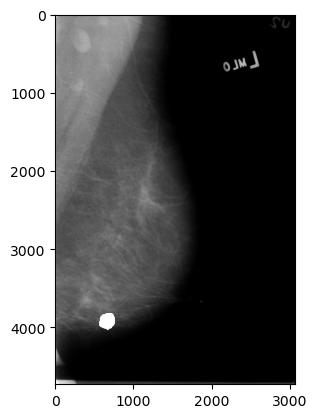

In [42]:
i = 1
subject_id = joined_df.iloc()[i]["Subject ID"]
breast = joined_df.iloc()[i]["breast"]
image_view = joined_df.iloc()[i]["image view"]
#cropped_image_filepath = parsed_df.iloc()[i]["cropped image filepath"]
fullimage_filepath = joined_df.iloc()[i]["fullimage filepath"]
roi_mask_filepath = joined_df.iloc()[i]["roi filepath"]

array = dicom.dcmread(fullimage_filepath).pixel_array
roi = dicom.dcmread(roi_mask_filepath).pixel_array

print(f"{subject_id} - {breast} {image_view}")
print(f"FULLIMAGE: {fullimage_filepath}")
print()
print(f"ROI: {roi_mask_filepath}")
plt.imshow(array, cmap=plt.cm.grey)
plt.imshow(roi, cmap=plt.cm.grey, alpha =(roi>0).astype(float))

### P_00038 - RIGHT CC

P_00038 - RIGHT CC
FULLIMAGE: /media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_RIGHT_CC/08-29-2017-DDSM-NA-28468/1.000000-full mammogram images-63304/1-1.dcm

ROI: /media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_RIGHT_CC_1/08-29-2017-DDSM-NA-83105/1.000000-ROI mask images-37851/1-2.dcm


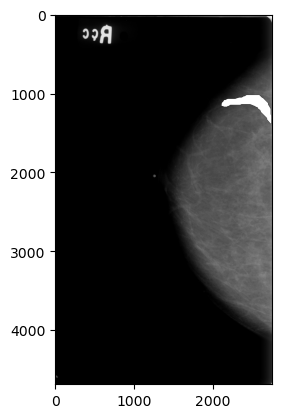

In [45]:
i = 2
subject_id = joined_df.iloc()[i]["Subject ID"]
breast = joined_df.iloc()[i]["breast"]
image_view = joined_df.iloc()[i]["image view"]
#cropped_image_filepath = parsed_df.iloc()[i]["cropped image filepath"]
fullimage_filepath = joined_df.iloc()[i]["fullimage filepath"]
roi_mask_filepath = joined_df.iloc()[i]["roi filepath"]

array = dicom.dcmread(fullimage_filepath).pixel_array
roi = dicom.dcmread(roi_mask_filepath).pixel_array

print(f"{subject_id} - {breast} {image_view}")
print(f"FULLIMAGE: {fullimage_filepath}")
print()
print(f"ROI: {roi_mask_filepath}")
plt.imshow(array, cmap=plt.cm.grey)
plt.imshow(roi, cmap=plt.cm.grey, alpha =(roi>0).astype(float))

P_00038 - RIGHT CC
FULLIMAGE: /media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_RIGHT_CC/08-29-2017-DDSM-NA-28468/1.000000-full mammogram images-63304/1-1.dcm

ROI: /media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_RIGHT_CC_2/08-29-2017-DDSM-NA-67143/1.000000-ROI mask images-07570/1-2.dcm


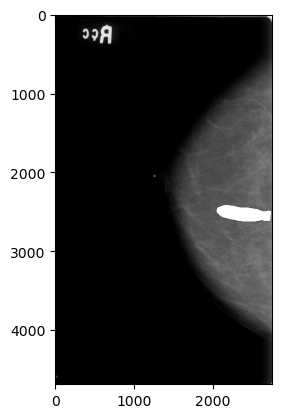

In [46]:
i = 3
subject_id = joined_df.iloc()[i]["Subject ID"]
breast = joined_df.iloc()[i]["breast"]
image_view = joined_df.iloc()[i]["image view"]
#cropped_image_filepath = parsed_df.iloc()[i]["cropped image filepath"]
fullimage_filepath = joined_df.iloc()[i]["fullimage filepath"]
roi_mask_filepath = joined_df.iloc()[i]["roi filepath"]

array = dicom.dcmread(fullimage_filepath).pixel_array
roi = dicom.dcmread(roi_mask_filepath).pixel_array

print(f"{subject_id} - {breast} {image_view}")
print(f"FULLIMAGE: {fullimage_filepath}")
print()
print(f"ROI: {roi_mask_filepath}")
plt.imshow(array, cmap=plt.cm.grey)
plt.imshow(roi, cmap=plt.cm.grey, alpha =(roi>0).astype(float))